In [12]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from utils import describe_data, plot_df_chart

In [13]:
# Import libraries
import yfinance as yf

In [14]:
TICKER = "ES=F"
df = yf.download(TICKER, period="max", interval="1D")

df.drop(columns=["Volume"], inplace=True)
df.columns = df.columns.droplevel("Ticker")
df.dropna(inplace=True)

df.tail()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open
Date,,,,
2026-05-18,7425.75,7454.25,7373.50,7410.00
2026-05-19,7378.00,7440.75,7354.25,7423.50
2026-05-20,7451.75,7458.00,7356.00,7377.00
2026-05-21,7466.00,7486.75,7407.50,7432.75
2026-05-22,7491.00,7524.00,7466.75,7467.00


## Daily return

In [15]:
df["Daily_return"] = 100 * (df["Close"] - df["Open"]) / df["Open"]

df.tail()

Price,Close,High,Low,Open,Daily_return
Date,,,,,
2026-05-18,7425.75,7454.25,7373.50,7410.00,0.212551
2026-05-19,7378.00,7440.75,7354.25,7423.50,-0.612918
2026-05-20,7451.75,7458.00,7356.00,7377.00,1.013285
2026-05-21,7466.00,7486.75,7407.50,7432.75,0.447345
2026-05-22,7491.00,7524.00,7466.75,7467.00,0.321414


In [16]:
plot_df_chart(
    df["Daily_return"],
    chart_type="bar",
    chart_title="Daily returns",
    yaxis_title="Daily Return (%)",
    width=1000,
    height=600,
)   

## Stats

In [17]:
df_stats, stats = describe_data(df["Daily_return"])

df_stats

,Value
Metric,
nobs,6484
Min %,-10.034861
Max %,12.223551
Mean %,0.041929
Median %,0.074622
Mode %,0.0
Variance,1.400638
Skewness,0.079282
Kurtosis,11.869069


## HMM

In [18]:
from hmmlearn.hmm import GaussianHMM
import numpy as np

# Use returns as the observation sequence
obs = df[["Daily_return"]].values  # shape (n, 1)

model = GaussianHMM(
    n_components=8,      # number of hidden states (bull/bear/sideways)
    # n_components=3,      # number of hidden states (bull/bear/sideways)
    covariance_type="full",
    n_iter=1000,
    random_state=42
)

model.fit(obs)

# Decode the most likely state sequence
states = model.predict(obs)
df["hmm_state"] = states

In [19]:
for state in range(model.n_components):
    mask = df["hmm_state"] == state
    print(f"\nState {state}:")
    print(f"  Mean return: {df.loc[mask, 'Daily_return'].mean():.4f}")
    print(f"  Std return:  {df.loc[mask, 'Daily_return'].std():.4f}")
    print(f"  Count: {mask.sum()}")


State 0:
  Mean return: -1.2341
  Std return:  0.5358
  Count: 149

State 1:
  Mean return: 0.1173
  Std return:  0.4337
  Count: 2837

State 2:
  Mean return: -0.0731
  Std return:  3.9551
  Count: 195

State 3:
  Mean return: -1.0296
  Std return:  0.3151
  Count: 195

State 4:
  Mean return: 0.1370
  Std return:  0.4105
  Count: 352

State 5:
  Mean return: 1.3417
  Std return:  0.4344
  Count: 73

State 6:
  Mean return: 1.1692
  Std return:  0.3210
  Count: 215

State 7:
  Mean return: -0.0241
  Std return:  1.3445
  Count: 2468


In [20]:
print(model.transmat_)

[[1.43713328e-001 1.21543176e-097 2.14362662e-033 6.36775901e-003
  5.41897241e-001 2.16397717e-001 1.07232900e-003 9.05516266e-002]
 [8.89740380e-010 9.10577410e-001 3.71165486e-244 8.52644819e-002
  2.45233263e-042 1.47657196e-179 5.51499719e-050 4.15810701e-003]
 [0.00000000e+000 0.00000000e+000 9.54718908e-001 0.00000000e+000
  0.00000000e+000 1.48219694e-323 0.00000000e+000 4.52810924e-002]
 [2.39907636e-001 1.17513424e-061 4.99118428e-003 7.62892380e-003
  5.12778012e-001 2.98300219e-028 2.34694243e-001 1.18771159e-010]
 [2.35660562e-001 6.79824222e-074 1.81510382e-172 9.95621187e-002
  3.62073505e-001 1.02818745e-001 1.99885069e-001 1.20933844e-012]
 [2.68357049e-015 5.28286799e-023 1.02019438e-271 8.07477226e-009
  7.83724016e-001 1.78876156e-001 3.73998192e-002 2.23286875e-065]
 [2.19551699e-001 7.75065667e-001 0.00000000e+000 1.31177438e-003
  6.02534306e-005 2.59239929e-033 4.01060645e-003 9.45409180e-059]
 [1.55392021e-131 4.20020214e-196 4.72644451e-003 4.00137270e-148
  9

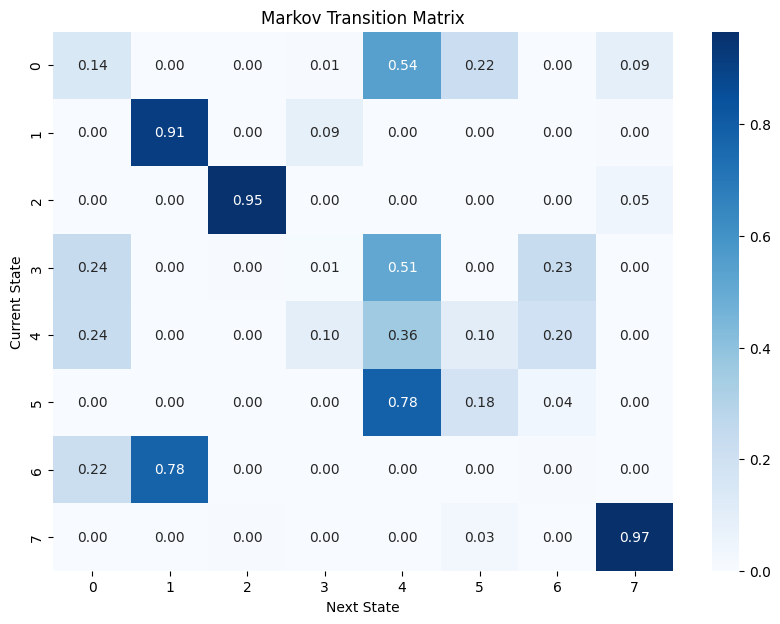

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

sns.heatmap(
    model.transmat_,
    annot=True,
    fmt=".2f",
    cmap="Blues"
)

plt.title("Markov Transition Matrix")
plt.xlabel("Next State")
plt.ylabel("Current State")

plt.show()

In [21]:
# from sklearn.model_selection import cross_val_score

# best_bic = np.inf
# for k in range(2, 10):
#     m = GaussianHMM(n_components=k, n_iter=500, random_state=42).fit(obs)
#     bic = -2 * m.score(obs) * len(obs) + k * np.log(len(obs))
#     print(f"k={k}, BIC={bic:.1f}")